### 1D Wave Equation Problem

$$
    u_{tt} = c ^ 2 u_{xx} \quad \text{for} \quad 0 \leq x \leq L
$$

With boundary conditions and initial condition:

$$
    u(0 , t) = u(L , t) = 0 \\
    u(x,0) := u_0(x) \\
    u_t(x,0) := v_0(x)
$$

The general solution is:

$$
    \boxed{u(x,t) = \sum_{n=1}^{\infty} \left[ a_n \cos(\omega_n t) + b_n \sin(\omega_n t) \right] \sin\left(\frac{n\pi x}{L}\right)}
$$

With:

$$
    a_n = \frac{2}{L} \int_0^L u_0(x) \sin\left(\frac{n\pi x}{L}\right) dx \\
    b_n = \frac{2}{\omega_n L} \int_0^L v_0(x) \sin\left(\frac{n\pi x}{L}\right) dx
$$

And $\omega_n = \frac{cn\pi}{L}$.

This is the complete solution provided by a linear combination of standing waves

In [1]:
import numpy as np
from scipy.integrate import quad_vec

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

In [2]:
# Parameters
Nx = 1000  # Spatial points
L = 2 * np.pi
x = np.linspace(0, L, Nx)

Nt = 100  # Time points
T = 2 * np.pi
t = np.linspace(0, T, Nt)

In [3]:
# Initial conditions
u0 = lambda x: 2 * np.exp(- 0.5 * ((x - L / 2) / 0.5) ** 2) # Gaussian
v0 = lambda x: 0  # Explicitly state zero initial velocity

In [4]:
# Wave speed
c = 2.0

# Number of modes
N_modes = 200
n = np.arange(1, N_modes + 1, 1)
omega_n = c * n * np.pi / L

In [5]:
# Compute Fourier coefficients a_n
def compute_a_coefficients(u0_func, n_vals, L):
    def integrand_a(x):
        return u0_func(x) * np.sin(np.outer(n_vals * np.pi / L, x)) # Using np.outer()
    
    result = quad_vec(integrand_a, 0, L)[0]
    return (2 / L) * result

# Compute Fourier coefficients b_n  
def compute_b_coefficients(v0_func, n_vals, L, omega_n):
    def integrand_b(x):
        return v0_func(x) * np.sin(n_vals * np.pi * x / L) # Using broadcasting
    
    result = quad_vec(integrand_b, 0, L)[0]
    return ((2 / L) * result / omega_n)[:, np.newaxis]

# Compute coefficients
a_n = compute_a_coefficients(u0, n, L)
b_n = compute_b_coefficients(v0, n, L, omega_n)

In [6]:
a_n.shape

(200, 1)

In [7]:
b_n.shape

(200, 1)

In [8]:
n_vals = np.arange(1, len(a_n) + 1, 1)

# Spatial basis functions: shape (n_modes, Nx)
spatial = np.sin(np.outer(n_vals * np.pi / L, x))

# Time-dependent coefficients for each mode: shape (n_modes, Nt)
time_cos = np.cos(np.outer(omega_n, t))  # a_n * cos(ω_n t)
time_sin = np.sin(np.outer(omega_n, t))  # b_n * sin(ω_n t)

# Scale by coefficients
time_cos_scaled = a_n * time_cos
time_sin_scaled = b_n * time_sin

# Combine: (n_modes, Nt)
time_total = time_cos_scaled + time_sin_scaled

# Matrix multiplication: (Nx, n_modes) @ (n_modes, Nt) = (Nx, Nt)
u = (spatial.T @ time_total)
u

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 2.55415678e-09,  1.95679366e-09,  8.32686254e-09, ...,
         8.32686253e-09,  1.95679368e-09,  2.55415678e-09],
       [ 4.85739004e-09,  3.90777181e-09,  1.66840859e-08, ...,
         1.66840859e-08,  3.90777184e-09,  4.85739004e-09],
       ...,
       [ 4.85738975e-09,  3.90777359e-09,  1.66840929e-08, ...,
         1.66840929e-08,  3.90777362e-09,  4.85738975e-09],
       [ 2.55415609e-09,  1.95679432e-09,  8.32686644e-09, ...,
         8.32686643e-09,  1.95679434e-09,  2.55415609e-09],
       [-8.19140691e-17, -6.09059314e-17, -9.04048610e-18, ...,
        -9.04048610e-18, -6.09059314e-17, -8.19140691e-17]],
      shape=(1000, 100))

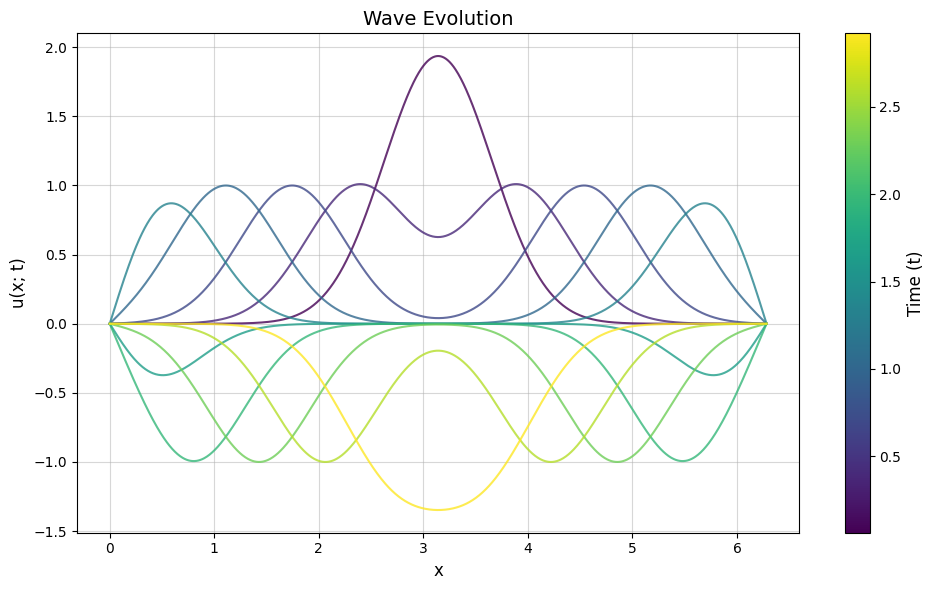

In [9]:
# Select time indices to plot
j_indices = np.arange(1, 50, 5)
t_selected = t[j_indices]

# Create a colormap based on time
cmap = plt.colormaps.get_cmap('viridis')
norm_t = (t_selected - t_selected.min()) / (t_selected.max() - t_selected.min())

# Create the figure
plt.figure(figsize = (10, 6))

# Plot each time snapshot with color based on time
for i, j in enumerate(j_indices):
    color = cmap(norm_t[i])
    plt.plot(x, u[:, j], color = color, linewidth = 1.5, alpha = 0.8, 
             label=f't = {t[j]:.2f}')

plt.title("Wave Evolution", fontsize = 14)
plt.xlabel("x", fontsize = 12)
plt.ylabel("u(x; t)", fontsize = 12)

# Add a colorbar to show the time progression
sm = plt.cm.ScalarMappable(cmap = cmap, norm = plt.Normalize(vmin = t_selected.min(), vmax = t_selected.max()))
sm.set_array([])  # This line is needed for ScalarMappable
cbar = plt.colorbar(sm, ax = plt.gca())
cbar.set_label('Time (t)', fontsize = 12)

plt.grid(True, alpha = 0.5)
plt.tight_layout()
plt.show()

Animation saved


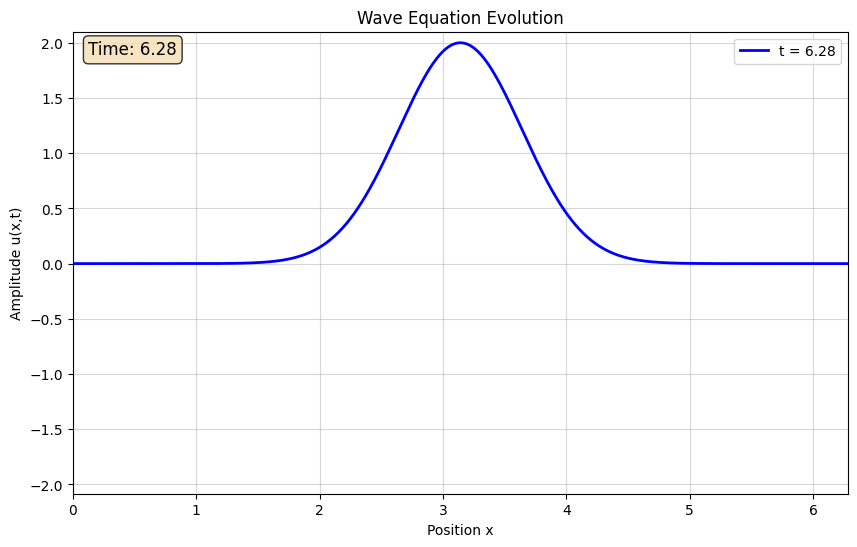

In [10]:
# Animation function
def animate_wave_solution(x, t, u, filename = 'Wave_Evolution.gif', fps = 30):

    fig, ax = plt.subplots(figsize = (10, 6))
    
    # Plot initial frame
    line, = ax.plot(x, u[:, 0], 'b-', linewidth = 2, label = f't = {t[0]:.2f}')
    ax.set_xlim([x.min(), x.max()])
    ax.set_ylim([u.min() - 0.1, u.max() + 0.1])
    ax.set_xlabel('Position x')
    ax.set_ylabel('Amplitude u(x,t)')
    ax.set_title('Wave Equation Evolution')
    ax.grid(True, alpha = 0.5)
    ax.legend(loc = 'upper right')
    
    # Time label
    time_text = ax.text(0.02, 0.95, '', transform = ax.transAxes, fontsize = 12,
                       bbox = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.8))
    
    def update(frame):
        # Update wave profile
        line.set_ydata(u[:, frame])
        
        # Update time label
        time_text.set_text(f'Time: {t[frame]:.2f}')
        
        # Update legend
        ax.legend([f't = {t[frame]:.2f}'], loc = 'upper right')
        
        return line, time_text
    
    # Create animation
    ani = FuncAnimation(fig, update, frames = len(t), 
                       interval=1000 / fps, blit = True)
    
    # Save as GIF
    ani.save(filename, writer = PillowWriter(fps = fps))
    print("Animation saved")
    
    return None

# Example usage (assuming you have already computed x, t, and u):
animate_wave_solution(x, t, u)